In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch
from torchvision import datasets, transforms
from PIL import Image
import os
import numpy as np
import cv2
from torchinfo import summary
from tqdm import tqdm
import json

# Download Dataset

In [2]:

# # Download MNIST datasets
# transform = transforms.ToTensor()
# train_dataset = datasets.MNIST(root='../Datasets/MNIST', train=True, download=True, transform=transform)
# test_dataset = datasets.MNIST(root='../Datasets/MNIST', train=False, download=True, transform=transform)

# # Create directories for each class
# os.makedirs('../Datasets/MNIST/train', exist_ok=True)
# os.makedirs('../Datasets/MNIST/test', exist_ok=True)
# for i in range(10):
#     os.makedirs(f'../Datasets/MNIST/train/{i}', exist_ok=True)
#     os.makedirs(f'../Datasets/MNIST/test/{i}', exist_ok=True)

# # Function to save a balanced small subset
# def save_subset(dataset, folder, n_per_class=500, seed=42):
#     g = torch.Generator().manual_seed(seed)
#     indices = torch.randperm(len(dataset), generator=g)
#     counts = {i: 0 for i in range(10)}
#     for idx in indices:
#         img, label = dataset[idx]
#         if counts[label] < n_per_class:
#             img_pil = transforms.ToPILImage()(img)
#             img_pil.save(f'{folder}/{label}/{counts[label]:04d}.png')
#             counts[label] += 1
#         if all(c >= n_per_class for c in counts.values()):
#             break

# # Save subsets (adjust n_per_class for size; here ~5000 train, ~1000 test)
# save_subset(train_dataset, '../Datasets/MNIST/train', 500)
# save_subset(test_dataset, '../Datasets/MNIST/test', 100)
# print("Small MNIST subset saved as image files.")
# from torchvision import datasets, transforms

# Load Configs

In [3]:
import yaml

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)


root_dir = config['data']['root_dir']
train_dir = os.path.join(root_dir, config['data']['train_folder'])
test_dir = os.path.join(root_dir, config['data']['test_folder'])
size = config['hyperparameters']["img_size"]
brightness_jitter = tuple(config['hyperparameters']["brightness_jitter"])
batch_size = config['hyperparameters']["batch_size"]
lr = config['hyperparameters']["lr"]
epochs = config['hyperparameters']["epochs"]

device = torch.device('cuda')

print("Configs Loaded Successfuly")

Configs Loaded Successfuly


# Dataloader

In [4]:

class ImageClassification_Dataloader(Dataset):
    def __init__(self, dir, transform=None):
        
        self.image_paths = []
        self.class_labels = []
        self.transforms = transform

        classes = sorted(os.listdir(dir))

        for class_label in classes:
            class_dir = os.path.join(dir, class_label)

            for img in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img))
                self.class_labels.append(int(class_label))        
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        label = self.class_labels[idx]

        if self.transforms:
            img = self.transforms(img)

        return img, label


imageclassification_transforms_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size),
    transforms.ColorJitter(brightness=brightness_jitter),
    ])


imageclassification_transforms_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size),
    transforms.ColorJitter(brightness=brightness_jitter),
    ])



In [155]:

train_dataset = ImageClassification_Dataloader(train_dir, transform=imageclassification_transforms_train)
test_dataset = ImageClassification_Dataloader(test_dir, transform=imageclassification_transforms_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Model Architecture

In [6]:

class ImageClassification_Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, 5, 1, 0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 32, 3),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01),
        )

        self.flatten = nn.Flatten()

        self.mlp = nn.Sequential(
            nn.Linear(32*216*216, 32),
            nn.Dropout(0.25),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        features = self.flatten(features)
        # return features
        return self.mlp(features)


# Initialization

In [11]:

model = ImageClassification_Model().to(device)
model.train()
optimizer = optim.AdamW(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "val_loss": []}

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassification_Model                [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 216, 216]         --
│    └─Conv2d: 2-1                       [1, 32, 220, 220]         2,432
│    └─BatchNorm2d: 2-2                  [1, 32, 220, 220]         64
│    └─LeakyReLU: 2-3                    [1, 32, 220, 220]         --
│    └─Conv2d: 2-4                       [1, 64, 218, 218]         18,496
│    └─BatchNorm2d: 2-5                  [1, 64, 218, 218]         128
│    └─LeakyReLU: 2-6                    [1, 64, 218, 218]         --
│    └─Conv2d: 2-7                       [1, 32, 216, 216]         18,464
│    └─BatchNorm2d: 2-8                  [1, 32, 216, 216]         64
│    └─LeakyReLU: 2-9                    [1, 32, 216, 216]         --
├─Flatten: 1-2                           [1, 1492992]              --
├─Sequential: 1-3                        [1, 10]                   --
│  

# Training Loop

In [12]:

def validate(model, loader, device, criterion):
    
    model.eval()

    total_loss = 0.0
    total_samples = 0

    pbar = tqdm(loader, desc="Validating", leave=False, unit='batch')

    with torch.no_grad():
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)
            
            total_samples += len(imgs)
            total_loss +=  loss.item() * len(imgs)

            pbar.set_postfix({"Loss": loss.item()})

    return total_loss / total_samples



In [34]:

best_loss = float('inf')

for i in range(epochs):
    model.train()
    total_loss = 0.0
    total_samples = 0

    pbar = tqdm(train_loader, desc=f"Epoch {i+1}/{epochs}", leave=True, unit='batch')

    for imgs, labels in pbar:
        optimizer.zero_grad()

        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_samples += len(imgs)
        total_loss +=  loss.item() * len(imgs)

        pbar.set_postfix({"Loss": loss.item()}, refresh=False)

    train_loss = total_loss / total_samples
    val_loss = validate(model, test_loader, device, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {i+1}: Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f}")

    if best_loss > val_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_weights.pth")
        print("Model Saved!\n")


with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=4)

print("Training Complete!")



        


Epoch 1/3: 100%|██████████| 157/157 [00:13<00:00, 11.33batch/s, Loss=0]       


Epoch 1: Train Loss: 1.91, Val Loss: 4.88
Model Saved!



Epoch 2/3: 100%|██████████| 157/157 [00:14<00:00, 10.98batch/s, Loss=0]      


Epoch 2: Train Loss: 1.93, Val Loss: 5.00


Epoch 3/3: 100%|██████████| 157/157 [00:13<00:00, 11.41batch/s, Loss=0]      


Epoch 3: Train Loss: 1.79, Val Loss: 4.84
Model Saved!

Training Complete!


# Evaluation

Model Loaded Successfully


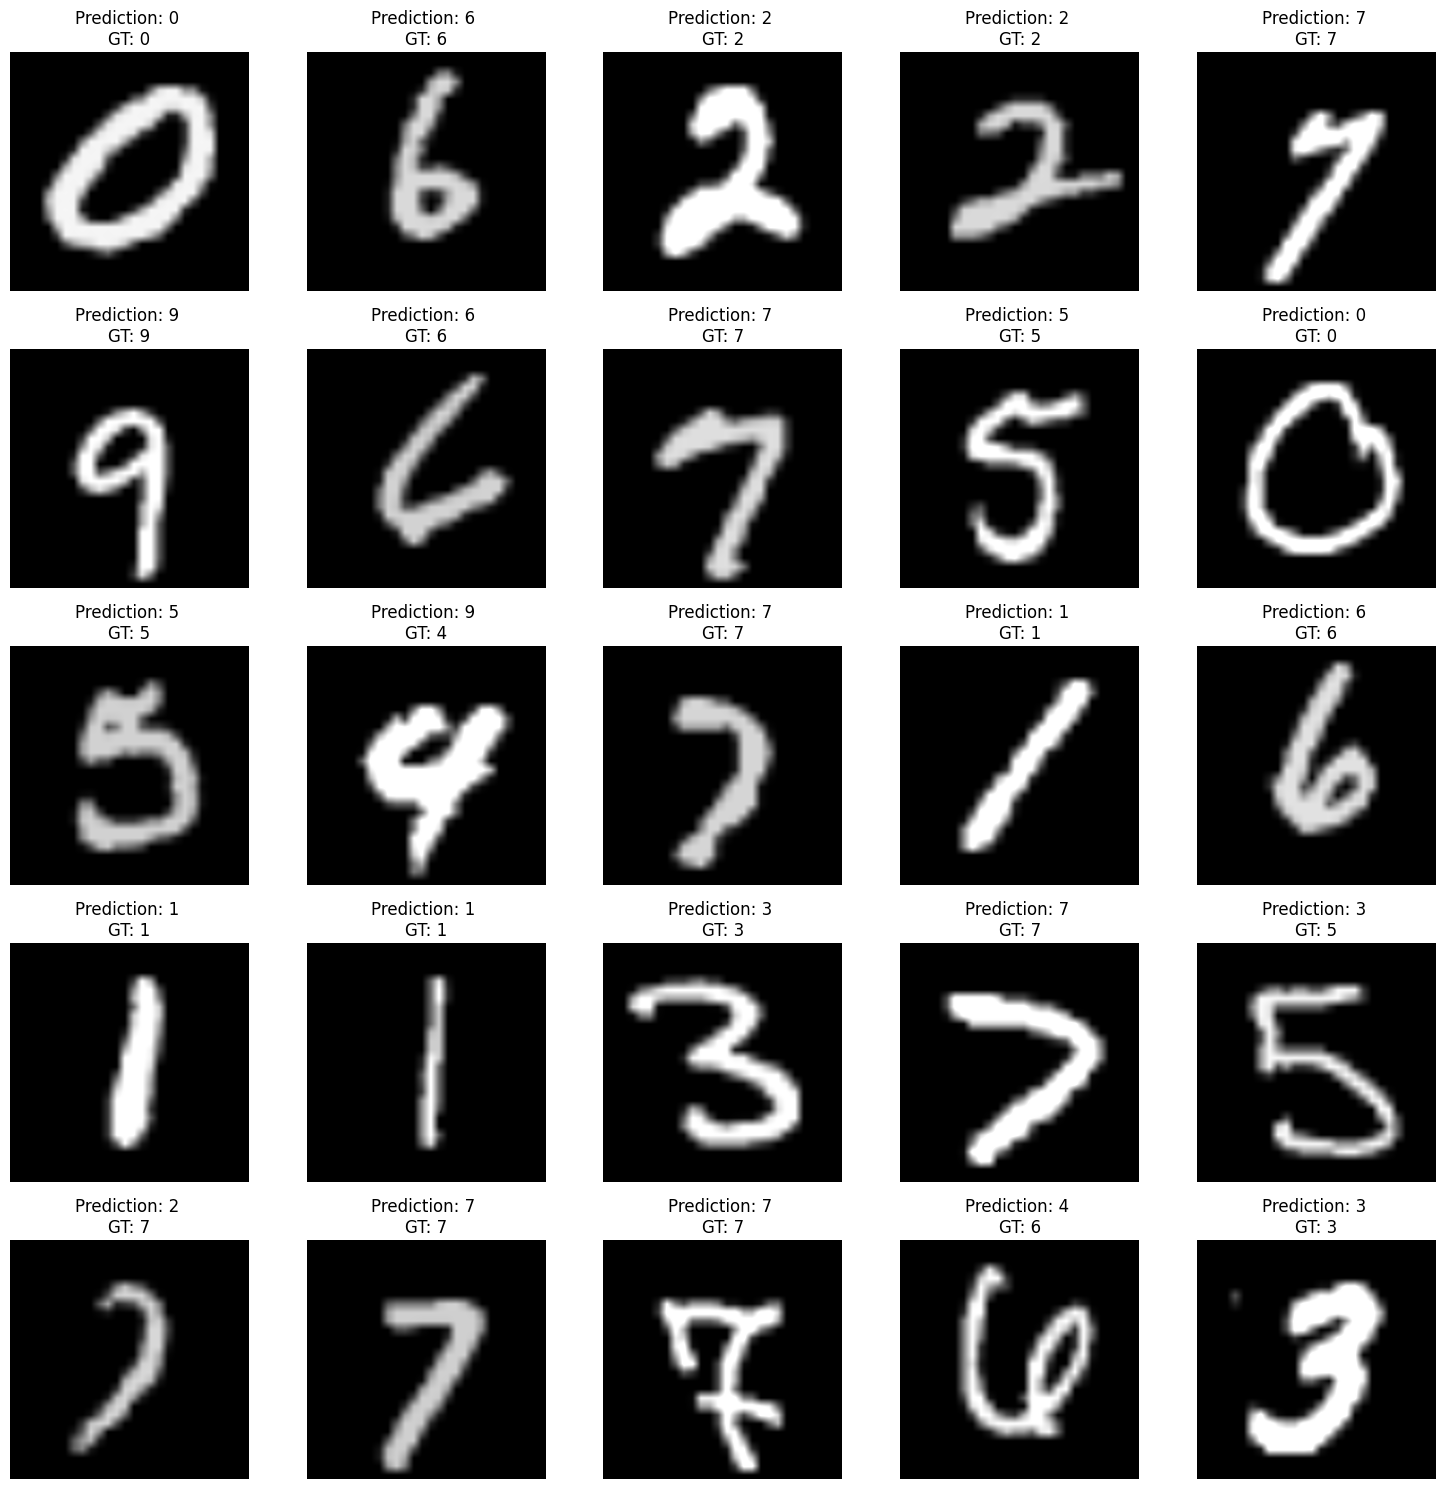

In [169]:
import random 
import matplotlib.pyplot as plt

model = ImageClassification_Model()
model.load_state_dict(torch.load('best_weights.pth'))
model = model.to(device)
model.eval()
print("Model Loaded Successfully")

def Qualitative_Analysis(model, loader, n=5):

    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)

    batch_size = len(imgs)

    sample_indices = random.sample(range(0, batch_size), k=n*n)

    selected_imgs, selected_labels = imgs[sample_indices], labels[sample_indices]

    predictions = model(selected_imgs)
    predictions = torch.argmax(predictions, axis=1, keepdim=False)

    fig, axes = plt.subplots(n, n, figsize=(n*3, n*3))

    if n==1:
        axes = np.array([axes])

    axes = axes.flatten()

    for i in range(n*n):
        img_np = selected_imgs[i].cpu().permute(1, 2, 0).numpy()
        axes[i].imshow(img_np)
        axes[i].set_title(f"Prediction: {predictions[i]} \nGT: {selected_labels[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
Qualitative_Analysis(model, test_loader, n=5)
